In [1]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_tickets.csv.zip to customer_support_tickets.csv.zip


In [2]:
import zipfile
import os

zip_file = "customer_support_tickets.csv.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("support_ticket_data")

os.listdir("support_ticket_data")

['customer_support_tickets.csv']

In [3]:
import pandas as pd

df = pd.read_csv("support_ticket_data/customer_support_tickets.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape: (8469, 17)

Column Names:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
# Check missing values
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [5]:
# Remove columns that are not useful for ML prediction
df = df.drop(columns=["Ticket ID", "Customer Name", "Customer Email"])

# Fill missing text values
df["Resolution"] = df["Resolution"].fillna("No resolution yet")

# Convert date/time columns to datetime
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"])
df["First Response Time"] = pd.to_datetime(df["First Response Time"])
df["Time to Resolution"] = pd.to_datetime(df["Time to Resolution"])

# Check the updated dataset
print("New Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

New Shape: (8469, 14)

Missing Values:
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                         0
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [6]:
# Remove columns with many missing values
df = df.drop(columns=[
    "First Response Time",
    "Time to Resolution",
    "Customer Satisfaction Rating"
])

# Check dataset
print("Final Shape:", df.shape)
print("\nRemaining Missing Values:")
print(df.isnull().sum())

Final Shape: (8469, 11)

Remaining Missing Values:
Customer Age          0
Customer Gender       0
Product Purchased     0
Date of Purchase      0
Ticket Type           0
Ticket Subject        0
Ticket Description    0
Ticket Status         0
Resolution            0
Ticket Priority       0
Ticket Channel        0
dtype: int64


Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


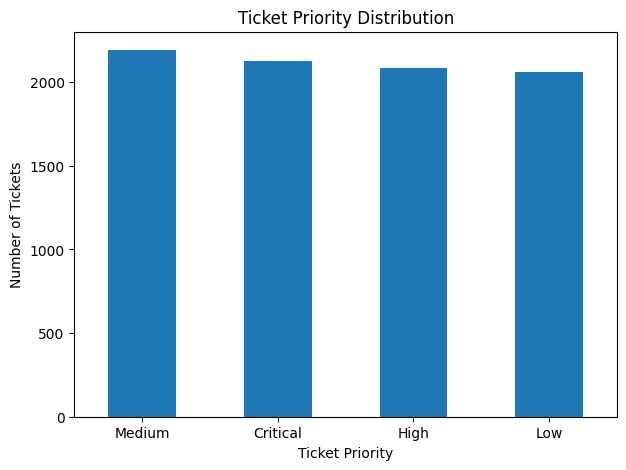

In [7]:
import matplotlib.pyplot as plt

# Count each ticket priority
priority_counts = df["Ticket Priority"].value_counts()

print(priority_counts)

# Plot the distribution
plt.figure(figsize=(7, 5))
priority_counts.plot(kind="bar")

plt.title("Ticket Priority Distribution")
plt.xlabel("Ticket Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

In [8]:
# Target variable
y = df["Ticket Priority"]

# Input features
X = df.drop(columns=["Ticket Priority"])

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Classes:")
print(y.unique())

X Shape: (8469, 10)
y Shape: (8469,)

Target Classes:
['Critical' 'Low' 'High' 'Medium']


In [9]:
# Create useful features from Date of Purchase

X["Purchase_Year"] = X["Date of Purchase"].dt.year
X["Purchase_Month"] = X["Date of Purchase"].dt.month
X["Purchase_Day"] = X["Date of Purchase"].dt.day
X["Purchase_Weekday"] = X["Date of Purchase"].dt.dayofweek

# Remove original date column
X = X.drop(columns=["Date of Purchase"])

print("New X Shape:", X.shape)
print("\nColumns:")
print(X.columns.tolist())

New X Shape: (8469, 13)

Columns:
['Customer Age', 'Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Channel', 'Purchase_Year', 'Purchase_Month', 'Purchase_Day', 'Purchase_Weekday']


In [10]:
from sklearn.preprocessing import OneHotEncoder

# Categorical columns
categorical_cols = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Channel"
]

# One-Hot Encoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Encode categorical data
X_encoded = encoder.fit_transform(X[categorical_cols])

print("Encoded Shape:", X_encoded.shape)

Encoded Shape: (8469, 57)


In [11]:
# Combine Ticket Subject and Ticket Description
X["Ticket_Text"] = (
    X["Ticket Subject"].fillna("") + " " +
    X["Ticket Description"].fillna("")
)

print(X["Ticket_Text"].head())

0    Product setup I'm having an issue with the {pr...
1    Peripheral compatibility I'm having an issue w...
2    Network problem I'm facing a problem with my {...
3    Account access I'm having an issue with the {p...
4    Data loss I'm having an issue with the {produc...
Name: Ticket_Text, dtype: object


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_text = tfidf.fit_transform(X["Ticket_Text"])

print("TF-IDF Shape:", X_text.shape)

TF-IDF Shape: (8469, 1000)


In [13]:
from scipy.sparse import csr_matrix, hstack

# Numerical features
numerical_cols = [
    "Customer Age",
    "Purchase_Year",
    "Purchase_Month",
    "Purchase_Day",
    "Purchase_Weekday"
]

X_numeric = csr_matrix(X[numerical_cols].values)

# Combine:
# TF-IDF text + categorical encoded + numerical features
X_final = hstack([
    X_text,
    csr_matrix(X_encoded),
    X_numeric
])

print("Final Feature Shape:", X_final.shape)

Final Feature Shape: (8469, 1062)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6775, 1062)
Testing data: (1694, 1062)


In [15]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Retrain Logistic Regression with more iterations

model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model retrained successfully!")

Model retrained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver="saga",
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

print("Final model training completed!")

Final model training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [18]:
from sklearn.metrics import accuracy_score, classification_report

# Predict ticket priorities
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.26092089728453366
Accuracy (%): 26.092089728453367

Classification Report:
              precision    recall  f1-score   support

    Critical       0.25      0.28      0.27       426
        High       0.28      0.15      0.19       417
         Low       0.26      0.06      0.10       413
      Medium       0.26      0.54      0.35       438

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.23      1694
weighted avg       0.26      0.26      0.23      1694



In [21]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.26092089728453366
Accuracy (%): 26.092089728453367

Classification Report:
              precision    recall  f1-score   support

    Critical       0.25      0.28      0.27       426
        High       0.28      0.15      0.19       417
         Low       0.26      0.06      0.10       413
      Medium       0.26      0.54      0.35       438

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.23      1694
weighted avg       0.26      0.26      0.23      1694



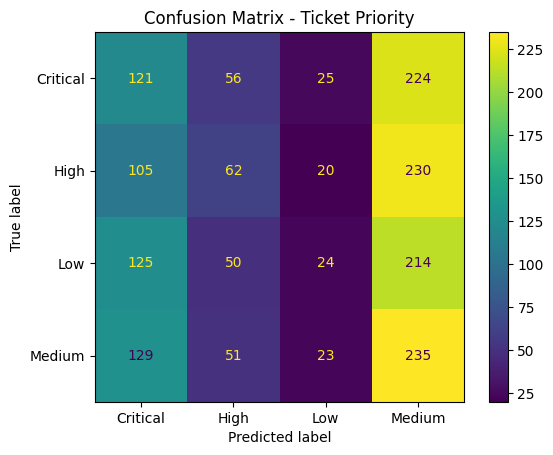

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Ticket Priority")
plt.show()

In [23]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Create Linear SVM model
svm_model = LinearSVC(
    random_state=42,
    max_iter=3000
)

# Train
svm_model.fit(X_train, y_train)

# Predict
svm_pred = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM Accuracy (%):", svm_accuracy * 100)

Linear SVM Accuracy: 0.24321133412042503
Linear SVM Accuracy (%): 24.321133412042503


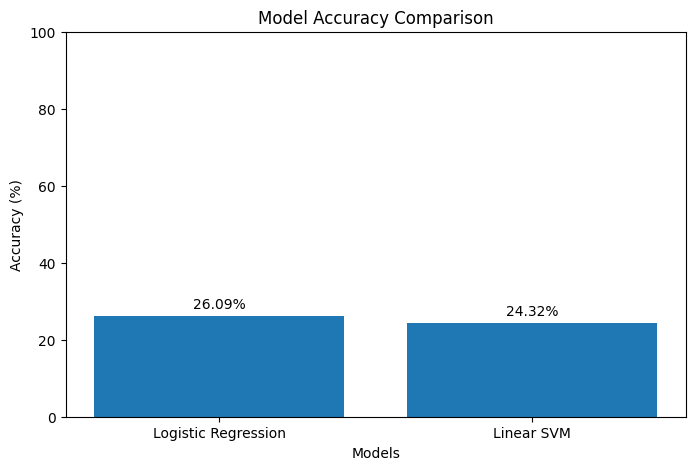

In [24]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Linear SVM"]
accuracies = [accuracy * 100, svm_accuracy * 100]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()

In [25]:
# Example new support ticket

new_ticket = "My laptop is not working and I need urgent technical support."

# Convert the new text using the trained TF-IDF vectorizer
new_text_features = tfidf.transform([new_ticket])

# Create empty features for the remaining columns
import numpy as np
from scipy.sparse import csr_matrix, hstack

new_extra_features = csr_matrix(
    np.zeros((1, X_final.shape[1] - X_text.shape[1]))
)

# Combine text + remaining features
new_features = hstack([
    new_text_features,
    new_extra_features
])

# Predict priority
prediction = model.predict(new_features)

print("Support Ticket:")
print(new_ticket)
print("\nPredicted Priority:", prediction[0])

Support Ticket:
My laptop is not working and I need urgent technical support.

Predicted Priority: Medium
